# U.S. Electricity Revenue Analysis

> **Important:** The dataset contains U.S. states as well as regional and national aggregate rows. It also contains an `all sectors` category alongside individual sectors. These must be handled carefully to avoid double-counting.


## Business task

Analyze how reported U.S. electricity revenue has changed over time and identify which states contribute the most revenue.

## Stakeholder Questions

This analysis aims to answer the following questions:

- What time period does the dataset cover, and are all years complete?
- How has total electricity revenue changed over time?
- Which states generate the highest cumulative electricity revenue?
- How do annual revenue trends differ among the top revenue-generating states?
- Do the Residential, Commercial, and Industrial sectors exhibit recurring seasonal demand patterns?
- Which months consistently experience the highest electricity demand in each sector?
- How has annual electricity demand evolved within the Residential, Commercial, and Industrial sectors?
- What differences can be observed between consumer-oriented sectors (Residential and Commercial) and the Industrial sector in terms of long-term demand and seasonality?

## Scope

This is an exploratory case study. It does not attempt to establish causation or produce a production-grade forecast.

# 2. Prepare

## Data source

The analysis uses a cleaned CSV file containing annual/monthly electricity observations by location and sector. Source : Kaggle : US_electricity_prices

Expected columns include:

- `year`
- `month`
- `stateDescription`
- `sectorName`
- `customers`
- `price`
- `revenue`



In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Update this path only if your file moves.
file_path = Path(
    r"C:\Users\nevez\OneDrive\Desktop\Data eng-analysis\clean_data"
    r"\clean_data_electricity_us.csv"
)

if not file_path.exists():
    raise FileNotFoundError(
        f"CSV file not found:\n{file_path}\n\n"
        "Update the file_path variable so it points to local CSV file."
    )

df_raw = pd.read_csv(file_path)
print(f"Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.")
df_raw.head(10)

Loaded 85,870 rows and 8 columns.


,year,month,stateDescription,sectorName,customers,price,revenue,sales
0,2001,1,Wyoming,all sectors,NaN,4.31,48.13,"1,116.17"
1,2001,1,Wyoming,commercial,NaN,5.13,12.68,247.09
2,2001,1,Wyoming,industrial,NaN,3.26,19.61,602.30
3,2001,1,Wyoming,other,NaN,4.75,0.77,16.17
4,2001,1,Wyoming,residential,NaN,6.01,15.07,250.61
5,2001,1,New England,all sectors,NaN,10.73,"1,139.90","10,622.88"
6,2001,1,South Carolina,other,NaN,6.57,5.28,80.41
7,2001,1,South Carolina,residential,NaN,7.36,225.82,"3,066.26"
8,2001,1,South Dakota,all sectors,NaN,5.85,46.99,803.24
9,2001,1,South Dakota,commercial,NaN,5.95,15.92,267.66


## Initial inspection

Before changing the data, we inspect its dimensions, column names, data types, missing values, and duplicates.

In [8]:
print("Shape:", df_raw.shape)    #We check the shape of the dataset
print("\nColumns:")
print(df_raw.columns.tolist())

print("\nData types and non-null counts:")   #Basic information for the dataset
df_raw.info()

print("\nMissing values:")                      
display(df_raw.isna().sum().sort_values(ascending=False))

print("\nExact duplicate rows:", df_raw.duplicated().sum())

Shape: (85870, 8)

Columns:
['year', 'month', 'stateDescription', 'sectorName', 'customers', 'price', 'revenue', 'sales']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85870 entries, 0 to 85869
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              85870 non-null  int64  
 1   month             85870 non-null  int64  
 2   stateDescription  85870 non-null  object 
 3   sectorName        85870 non-null  object 
 4   customers         59830 non-null  float64
 5   price             85870 non-null  float64
 6   revenue           85870 non-null  float64
 7   sales             85870 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 5.2+ MB

Missing values:


customers           26040
year                    0
month                   0
stateDescription        0
sectorName              0
price                   0
revenue                 0
sales                   0
dtype: int64


Exact duplicate rows: 0


## Information content of the dataframe

    Year range
    Distinct years/locations/sectors
    Unique names of states
    

In [9]:
print("Year range:", df_raw["year"].min(), "to", df_raw["year"].max())
print("Distinct location descriptions:", df_raw["stateDescription"].nunique())
print("Distinct sectors:", df_raw["sectorName"].nunique())

print("\nSector values:")
print(sorted(df_raw["sectorName"].dropna().unique()))

print("\nLocation descriptions:")
print(sorted(df_raw["stateDescription"].dropna().unique()))

Year range: 2001 to 2024
Distinct location descriptions: 62
Distinct sectors: 6

Sector values:
['all sectors', 'commercial', 'industrial', 'other', 'residential', 'transportation']

Location descriptions:
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'East North Central', 'East South Central', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Middle Atlantic', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Mountain', 'Nebraska', 'Nevada', 'New England', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pacific Contiguous', 'Pacific Noncontiguous', 'Pennsylvania', 'Rhode Island', 'South Atlantic', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'U.S. Total', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West North Central

## Preparation Notes

Before beginning the analysis, we took some time to better understand the structure of the dataset. During this exploration, we noticed that some columns contained more information than we initially expected, so we refined our approach before moving forward.

- **`stateDescription`** does not contain only U.S. states. It also includes the District of Columbia, census regions, divisions, and national aggregate entries. Since our objective is to compare states, we restrict the analysis to the individual states (and Washington, D.C., when appropriate).

- **`sectorName`** contains both individual sectors (Residential, Commercial, Industrial, Transportation, etc.) and an **All Sectors** category. Because the **All Sectors** records already represent the combined total across sectors, including them together with the individual sectors would result in double counting. To ensure consistent and accurate calculations, we use only the **All Sectors** records when analyzing total state revenue.

# 3. Process

## 3.1 Standardize column names and data types

In [10]:
df = df_raw.copy()

# Remove accidental spaces from column names.
df.columns = df.columns.str.strip()

required_columns = {
    "year", "month", "stateDescription", "sectorName",
    "customers", "price", "revenue"
}

missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

# Standardize text columns.
df["stateDescription"] = df["stateDescription"].astype("string").str.strip()
df["sectorName"] = df["sectorName"].astype("string").str.strip().str.lower()

# Convert analytical columns to numeric.
for column in ["year", "month", "customers", "price", "revenue"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df.head()

,year,month,stateDescription,sectorName,customers,price,revenue,sales
0,2001,1,Wyoming,all sectors,NaN,4.31,48.13,"1,116.17"
1,2001,1,Wyoming,commercial,NaN,5.13,12.68,247.09
2,2001,1,Wyoming,industrial,NaN,3.26,19.61,602.30
3,2001,1,Wyoming,other,NaN,4.75,0.77,16.17
4,2001,1,Wyoming,residential,NaN,6.01,15.07,250.61


## 3.2 Validate records

We check for missing keys, impossible values, duplicate rows, and coverage by year.

In [11]:
quality_summary = pd.Series({
    "rows": len(df),
    "duplicate_rows": df.duplicated().sum(),
    "missing_year": df["year"].isna().sum(),
    "missing_month": df["month"].isna().sum(),
    "missing_location": df["stateDescription"].isna().sum(),
    "missing_sector": df["sectorName"].isna().sum(),
    "missing_revenue": df["revenue"].isna().sum(),
    "negative_revenue": (df["revenue"] < 0).sum(),
    "invalid_month": (~df["month"].between(1, 12)).sum()
})

quality_summary

rows                85870
duplicate_rows          0
missing_year            0
missing_month           0
missing_location        0
missing_sector          0
missing_revenue         0
negative_revenue        2
invalid_month           0
dtype: int64

In [12]:
# Remove exact duplicates only. 
df = df.drop_duplicates().copy()

coverage_by_year = (
    df.groupby("year")
      .agg(
          rows=("revenue", "size"),
          non_null_revenue=("revenue", "count"),
          months=("month", "nunique"),
          locations=("stateDescription", "nunique"),
          sectors=("sectorName", "nunique")
      )
)

coverage_by_year

,rows,non_null_revenue,months,locations,sectors
year,,,,,
2001,3720,3720,12,62,5
2002,3720,3720,12,62,5
2003,3720,3720,12,62,5
2004,3720,3720,12,62,5
2005,3720,3720,12,62,5
2006,3720,3720,12,62,5
2007,3720,3720,12,62,5
2008,3720,3720,12,62,5
2009,3720,3720,12,62,5


## 3.3 Define valid state-level observations

The following list contains the 50 states plus the District of Columbia. Regional and national aggregates are excluded.

For state revenue analysis, we also retain only `all sectors` rows to prevent double-counting across sector totals.

In [13]:
state_names = {
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado",
    "Connecticut", "Delaware", "District of Columbia", "Florida", "Georgia",
    "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky",
    "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota",
    "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire",
    "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota",
    "Ohio", "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island",
    "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah", "Vermont",
    "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"
}

state_level = df[
    df["stateDescription"].isin(state_names)
    & df["sectorName"].eq("all sectors")
].copy()

print("State-level rows:", f"{len(state_level):,}")
print("Locations retained:", state_level["stateDescription"].nunique())
print("Years retained:", int(state_level["year"].min()), "to", int(state_level["year"].max()))

State-level rows: 14,127
Locations retained: 51
Years retained: 2001 to 2024


## 3.4 Investigate year completeness

A very low final-year value is not automatically a statistical outlier. It may represent partial-year data. We compare row, month, and state coverage before deciding whether to exclude it.

In [14]:
state_coverage_by_year = (
    state_level.groupby("year")
    .agg(
        total_revenue=("revenue", "sum"),
        rows=("revenue", "size"),
        months=("month", "nunique"),
        states=("stateDescription", "nunique")
    )
)

state_coverage_by_year.tail()

,total_revenue,rows,months,states
year,,,,
2020,"393,639.42",612,12,51
2021,"422,323.25",612,12,51
2022,"485,248.94",612,12,51
2023,"491,123.77",612,12,51
2024,"43,413.55",51,1,51


In [15]:
latest_year = int(state_level["year"].max())
latest_year_summary = state_coverage_by_year.loc[latest_year]

latest_year_complete = (
    latest_year_summary["months"] == 12
    and latest_year_summary["states"] == len(state_names)
)

print(f"Latest year: {latest_year}")
print(latest_year_summary)
print("\nAppears complete:", latest_year_complete)

Latest year: 2024
total_revenue   43,413.55
rows                51.00
months               1.00
states              51.00
Name: 2024, dtype: float64

Appears complete: False


### Analysis decision

The trend analysis below excludes the latest year **only when its coverage appears incomplete**. This is documented as a data-completeness decision, not as removal of a genuine extreme observation.

In [16]:
if latest_year_complete:
    analysis_end_year = latest_year
else:
    analysis_end_year = latest_year - 1

state_level_complete = state_level[state_level["year"] <= analysis_end_year].copy()

print(
    f"Trend-analysis period: "
    f"{int(state_level_complete['year'].min())}–{analysis_end_year}"
)

Trend-analysis period: 2001–2023


# 4. Analyze

## 4.1 Annual state-level revenue

This calculation sums `all sectors` revenue across the 50 states and District of Columbia for each year.

In [17]:
revenue_by_year = (
    state_level_complete.groupby("year")["revenue"]
    .sum()
    .sort_index()
)

revenue_by_year.to_frame("total_revenue").tail()

,total_revenue
year,
2019,"401,738.14"
2020,"393,639.42"
2021,"422,323.25"
2022,"485,248.94"
2023,"491,123.77"


## 4.2 Validate the aggregation

The sum of annual totals should equal the revenue sum in the filtered analytical dataset.

In [18]:
source_total = state_level_complete["revenue"].sum()
annual_total = revenue_by_year.sum()
difference = source_total - annual_total

print(f"Source total: {source_total:,.2f}")
print(f"Sum of annual totals: {annual_total:,.2f}")
print(f"Difference: {difference:,.10f}")

assert np.isclose(source_total, annual_total), "Aggregation validation failed."

Source total: 8,352,198.75
Sum of annual totals: 8,352,198.75
Difference: -0.0000000009


## 4.3 Plot annual revenue

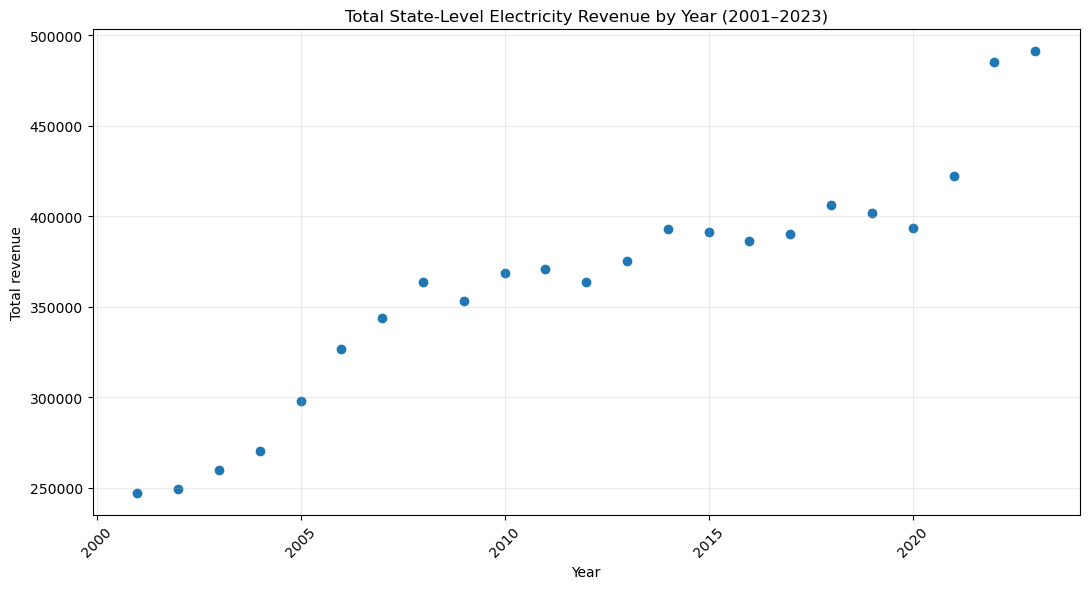

In [45]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(revenue_by_year.index, revenue_by_year.values)
ax.set(
    title=f"Total State-Level Electricity Revenue by Year ({int(revenue_by_year.index.min())}–{analysis_end_year})",
    xlabel="Year",
    ylabel="Total revenue"
)
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 4.4 Fit a linear trend

A first-degree polynomial is used as a descriptive summary of the long-term trend. It is not treated as a causal model or a forecast.

In [46]:
years = revenue_by_year.index.to_numpy(dtype=float)
revenues = revenue_by_year.to_numpy(dtype=float)

slope, intercept = np.polyfit(years, revenues, 1)
fitted_revenue = slope * years + intercept

residual_sum_squares = np.sum((revenues - fitted_revenue) ** 2)
total_sum_squares = np.sum((revenues - revenues.mean()) ** 2)
r_squared = 1 - residual_sum_squares / total_sum_squares

print(f"Estimated annual change: {slope:,.2f} revenue units per year")
print(f"R²: {r_squared:.3f}")

Estimated annual change: 9,079.15 revenue units per year
R²: 0.887


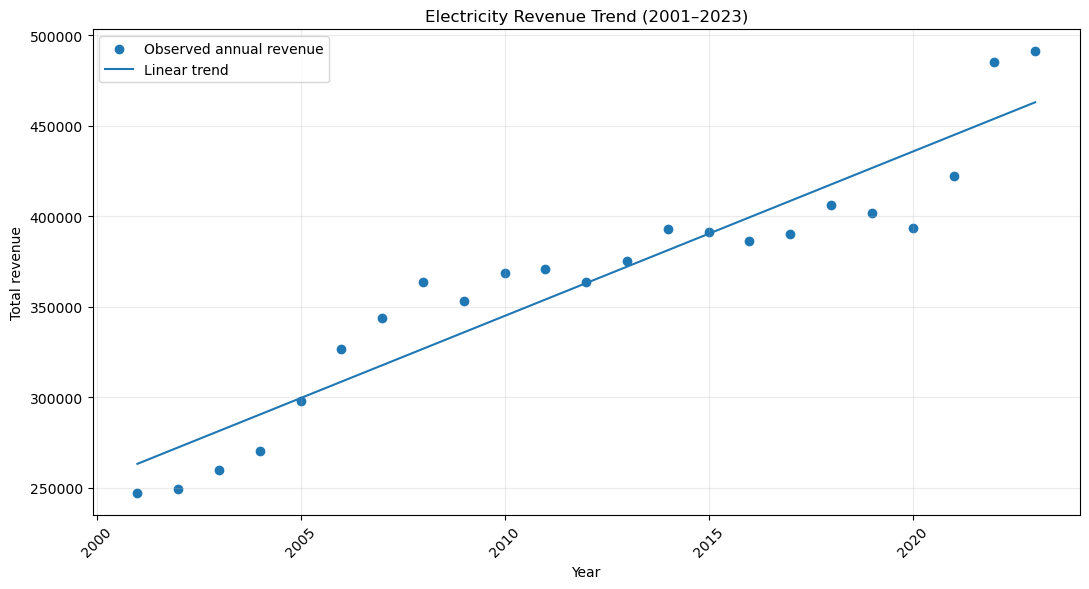

In [47]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(years, revenues, label="Observed annual revenue")
ax.plot(years, fitted_revenue, label="Linear trend")

ax.set(
    title=f"Electricity Revenue Trend ({int(years.min())}–{int(years.max())})",
    xlabel="Year",
    ylabel="Total revenue"
)
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation template

Complete this statement after running the notebook:

> From **[first year]** through **[last complete year]**, state-level electricity revenue shows a generally **[increasing/decreasing]** trend. The fitted line estimates an average annual change of **[slope]** revenue units. The R² value of **[R²]** indicates that a linear trend explains **[weak/moderate/strong]** variation in annual revenue.

## 4.5 Top ten states by cumulative revenue

The ranking is based on cumulative revenue during the complete analysis period.

In [48]:
state_revenue = (
    state_level_complete.groupby("stateDescription")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

top10_states = state_revenue.head(10)
top10_states.to_frame("cumulative_revenue")

,cumulative_revenue
stateDescription,
California,"872,897.06"
Texas,"780,404.22"
Florida,"538,570.84"
New York,"498,885.66"
Pennsylvania,"322,164.87"
Ohio,"308,245.70"
Illinois,"283,879.75"
Georgia,"277,719.87"
North Carolina,"258,156.68"


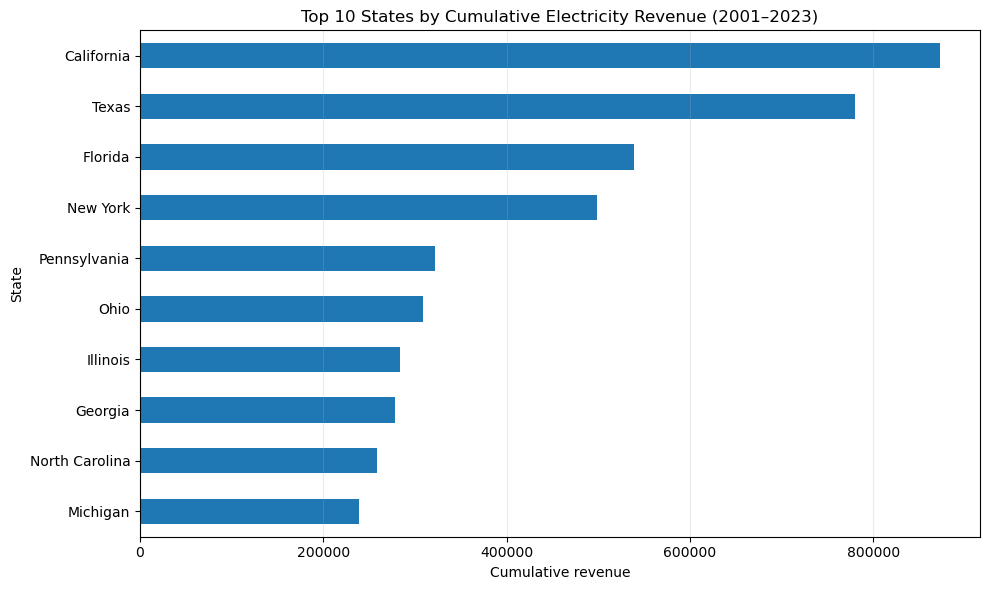

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

top10_states.sort_values().plot(kind="barh", ax=ax)

ax.set(
    title=f"Top 10 States by Cumulative Electricity Revenue ({int(years.min())}–{analysis_end_year})",
    xlabel="Cumulative revenue",
    ylabel="State"
)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## 4.6 Annual revenue trends for the top ten states

In [50]:
top10_names = top10_states.index

top10_revenue_by_year = (
    state_level_complete[
        state_level_complete["stateDescription"].isin(top10_names)
    ]
    .groupby(["year", "stateDescription"])["revenue"]
    .sum()
    .unstack("stateDescription")
    .sort_index()
)

top10_revenue_by_year.tail()

stateDescription,California,Florida,Georgia,Illinois,Michigan,New York,North Carolina,Ohio,Pennsylvania,Texas
year,,,,,,,,,,
2019,"42,290.06","25,103.43","13,739.61","13,228.03","11,700.91","20,883.53","12,892.93","14,229.12","14,281.86","36,910.42"
2020,"45,028.61","24,394.22","13,247.09","12,915.10","11,846.54","20,872.15","12,293.46","13,459.73","13,549.24","35,705.76"
2021,"48,589.10","25,764.33","14,333.23","13,754.31","12,910.02","22,782.82","12,612.20","14,423.86","14,288.77","39,797.33"
2022,"56,243.93","31,129.15","17,406.36","16,223.48","13,286.36","26,245.82","13,363.39","15,906.23","17,209.23","48,285.04"
2023,"58,917.74","33,862.75","16,012.45","15,573.31","13,320.32","25,480.31","14,656.34","16,318.75","17,382.16","48,634.82"


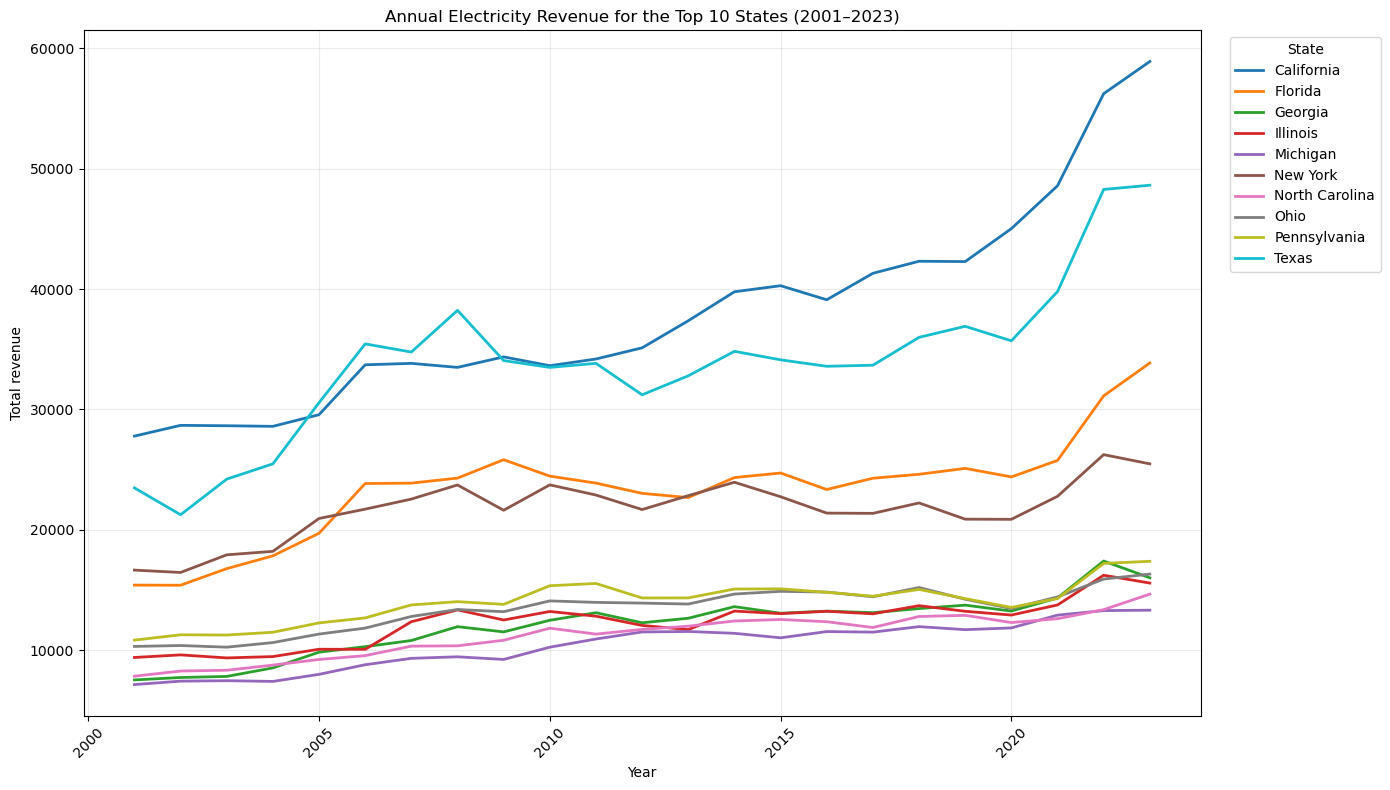

In [54]:
fig, ax = plt.subplots(figsize=(14, 8))

for state in top10_revenue_by_year.columns:
    ax.plot(
        top10_revenue_by_year.index,
        top10_revenue_by_year[state],
        linewidth=2,
        label=state
    )

ax.set(
    title=f"Annual Electricity Revenue for the Top 10 States ({int(years.min())}–{analysis_end_year})",
    xlabel="Year",
    ylabel="Total revenue"
)
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.25)
ax.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Electricity Demand by Season and Year

### Analytical question

How does electricity demand vary throughout the year for the Residential, Commercial, and Industrial sectors, and how has total demand changed over time?

### Method

We use electricity **sales** as a measure of demand and limit the analysis to three major sectors:

- Residential
- Commercial
- Industrial

Because sales are additive, monthly sales are summed across the observations belonging to the same sector and period.

Two complementary views are created:

1. A **seasonal demand profile**, showing the average demand for each calendar month across the complete years in the dataset.
2. An **annual demand trend**, showing total electricity demand for each sector in every year.

The incomplete final year is excluded to ensure that partial-year data do not distort the comparison.

,sectorName,year,month,total_demand
0,commercial,2001,1,"272,475.82"
1,commercial,2001,2,"244,400.57"
2,commercial,2001,3,"252,192.75"
3,commercial,2001,4,"243,181.60"
4,commercial,2001,5,"262,412.23"
5,commercial,2001,6,"286,974.87"
6,commercial,2001,7,"306,468.82"
7,commercial,2001,8,"316,865.80"
8,commercial,2001,9,"290,113.36"
9,commercial,2001,10,"268,133.06"


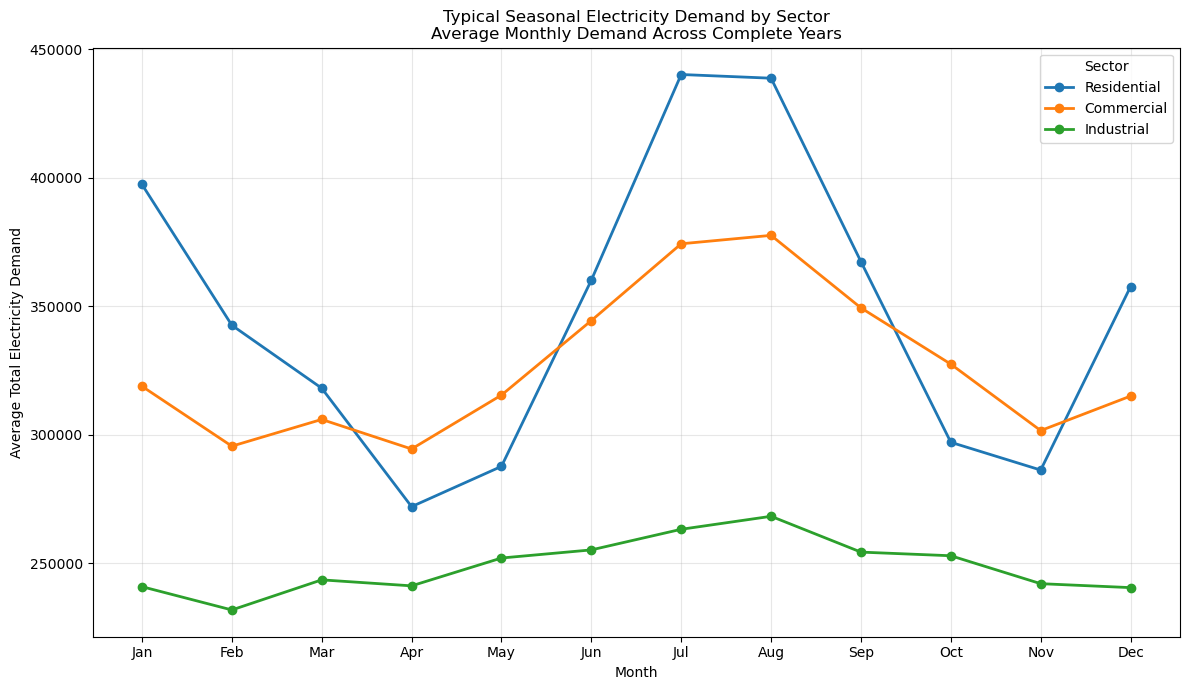

,sectorName,year,total_annual_demand
0,commercial,2001,"3,249,205.55"
1,commercial,2002,"3,313,489.82"
2,commercial,2003,"3,596,182.80"
3,commercial,2004,"3,691,274.19"
4,commercial,2005,"3,825,237.06"
5,commercial,2006,"3,899,231.09"
6,commercial,2007,"4,008,945.59"
7,commercial,2008,"4,008,400.46"
8,commercial,2009,"3,920,557.57"
9,commercial,2010,"3,990,598.09"


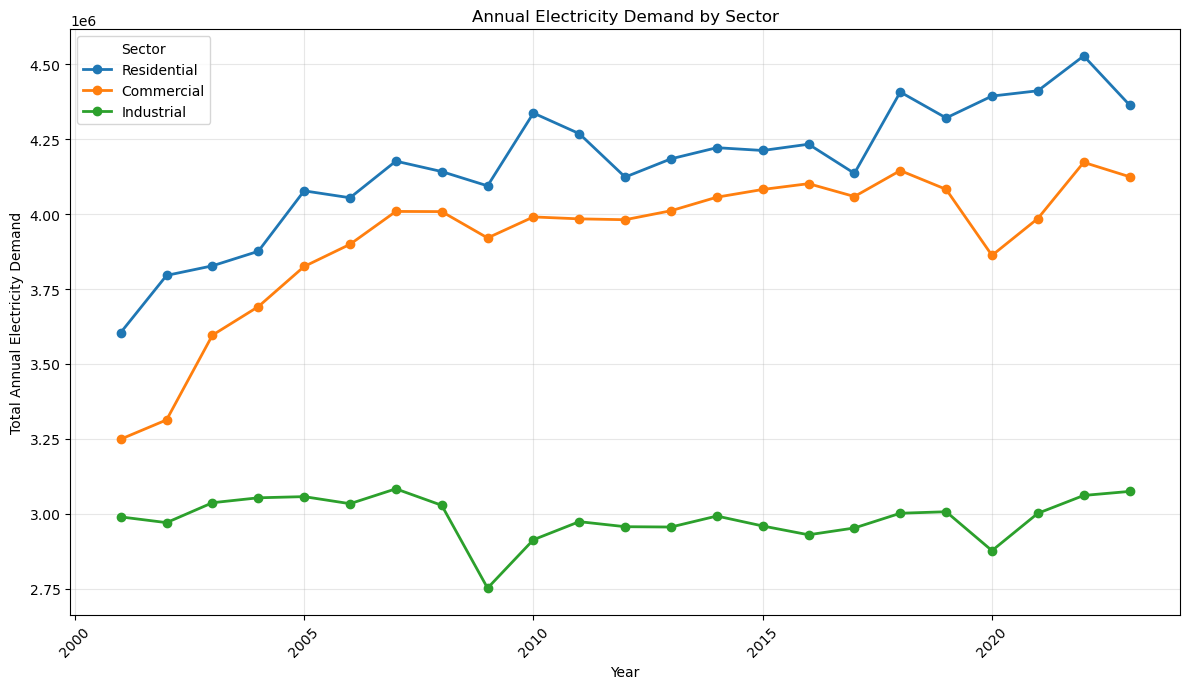

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# ------------------------------------------------------------
# 1. Create a separate working dataset
# ------------------------------------------------------------

demand_analysis = df.copy()

# ------------------------------------------------------------
# 2. Standardize the sector names
#
# Converting the values to lowercase prevents filtering errors
# caused by inconsistent capitalization or extra spaces.
# ------------------------------------------------------------

demand_analysis["sectorName"] = (
    demand_analysis["sectorName"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# 3. Keep only the sectors included in this analysis
# ------------------------------------------------------------

selected_sectors = [
    "residential",
    "commercial",
    "industrial"
]

demand_analysis = demand_analysis[
    demand_analysis["sectorName"].isin(selected_sectors)
].copy()

# ------------------------------------------------------------
# 4. Convert the required columns to numeric values
#
# Invalid values are converted to NaN so that they can be
# identified and removed safely.
# ------------------------------------------------------------

required_numeric_columns = [
    "year",
    "month",
    "sales"
]

for column in required_numeric_columns:
    demand_analysis[column] = pd.to_numeric(
        demand_analysis[column],
        errors="coerce"
    )

# ------------------------------------------------------------
# 5. Remove unusable observations
# ------------------------------------------------------------

demand_analysis = demand_analysis.dropna(
    subset=["year", "month", "sales"]
)

demand_analysis = demand_analysis[
    demand_analysis["month"].between(1, 12)
].copy()

demand_analysis = demand_analysis[
    demand_analysis["sales"] >= 0
].copy()

# Convert year and month to integers after removing missing values
demand_analysis["year"] = demand_analysis["year"].astype(int)
demand_analysis["month"] = demand_analysis["month"].astype(int)

# ------------------------------------------------------------
# 6. Exclude the incomplete final year
#
# Change 2024 below if your incomplete year is different.
# ------------------------------------------------------------

demand_analysis = demand_analysis[
    demand_analysis["year"] < 2024
].copy()

# ------------------------------------------------------------
# 7. Aggregate demand by sector, year, and month
#
# Sales are summed because they are additive.
# Each row now represents one sector in one specific month
# and year.
# ------------------------------------------------------------

monthly_demand_by_year = (
    demand_analysis
    .groupby(
        ["sectorName", "year", "month"],
        as_index=False
    )
    .agg(
        total_demand=("sales", "sum")
    )
)

# Display the first observations for validation
display(monthly_demand_by_year.head(15))

# ------------------------------------------------------------
# 8. Calculate the typical seasonal demand profile
#
# We first calculate each sector's total demand for each
# year-month combination. We then average matching calendar
# months across the years.
#
# For example, the January value represents the average of
# January demand across all complete years.
# ------------------------------------------------------------

seasonal_demand_profile = (
    monthly_demand_by_year
    .groupby(
        ["sectorName", "month"],
        as_index=False
    )
    .agg(
        average_monthly_demand=("total_demand", "mean")
    )
)

# Add readable month names
seasonal_demand_profile["month_name"] = (
    seasonal_demand_profile["month"]
    .apply(lambda month_number: calendar.month_abbr[month_number])
)

# ------------------------------------------------------------
# 9. Plot the seasonal demand profile
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

for sector in selected_sectors:

    sector_monthly_data = seasonal_demand_profile[
        seasonal_demand_profile["sectorName"] == sector
    ].sort_values("month")

    plt.plot(
        sector_monthly_data["month"],
        sector_monthly_data["average_monthly_demand"],
        marker="o",
        linewidth=2,
        label=sector.title()
    )

plt.xlabel("Month")
plt.ylabel("Average Total Electricity Demand")
plt.title(
    "Typical Seasonal Electricity Demand by Sector\n"
    "Average Monthly Demand Across Complete Years"
)

plt.xticks(
    ticks=range(1, 13),
    labels=[calendar.month_abbr[month] for month in range(1, 13)]
)

plt.legend(title="Sector")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Aggregate total demand by sector and year
#
# This produces one annual demand value for each sector.
# ------------------------------------------------------------

annual_demand_by_sector = (
    monthly_demand_by_year
    .groupby(
        ["sectorName", "year"],
        as_index=False
    )
    .agg(
        total_annual_demand=("total_demand", "sum")
    )
)

# Display the annual table for validation
display(annual_demand_by_sector.head(15))

# ------------------------------------------------------------
# 11. Plot annual electricity demand for each sector
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

for sector in selected_sectors:

    sector_annual_data = annual_demand_by_sector[
        annual_demand_by_sector["sectorName"] == sector
    ].sort_values("year")

    plt.plot(
        sector_annual_data["year"],
        sector_annual_data["total_annual_demand"],
        marker="o",
        linewidth=2,
        label=sector.title()
    )

plt.xlabel("Year")
plt.ylabel("Total Annual Electricity Demand")
plt.title(
    "Annual Electricity Demand by Sector"
)

plt.legend(title="Sector")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusions

The seasonal demand profiles reveal clear differences among the three major electricity sectors.

- The **Residential** and **Commercial** sectors exhibit a pronounced seasonal pattern, with demand peaking around **January** and **August** across the complete years included in the analysis.

- In both sectors, the **August peak is consistently larger than the January peak**, indicating stronger electricity demand during the summer months.

- The **Industrial** sector displays a much flatter seasonal profile. Although a modest increase in demand is visible around **August**, the overall variation throughout the year is considerably smaller than that observed in the Residential and Commercial sectors.

The annual demand trends also differ across sectors.

- Total electricity demand in the **Residential** and **Commercial** sectors shows a gradual upward trend over the study period, suggesting a long-term increase in electricity consumption.

- In contrast, the **Industrial** sector remains relatively stable over time, with only minor year-to-year fluctuations and no clear long-term growth trend.

Overall, the analysis indicates that seasonal effects are much more pronounced in the Residential and Commercial sectors, while electricity demand in the Industrial sector remains comparatively steady throughout both the year and the study period.

In [19]:
import os

print(os.getcwd())

C:\Users\nevez\Project
